In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
with open("names.txt") as f:
    words=f.read().splitlines()

In [3]:
chars=list(sorted(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={v:k for k,v in stoi.items()}

In [4]:
# Dataset
block_size=3

def build_dataset(words,block_size=3):
    X,Y=[],[]

    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

torch.Size([182495, 3]) torch.Size([182495])
torch.Size([22855, 3]) torch.Size([22855])
torch.Size([22796, 3]) torch.Size([22796])


In [5]:
sample=torch.randn((2,20))
sample2=torch.ones((1,20))
print(sample)
print(sample2*sample)

tensor([[-0.1166,  0.2190, -0.0082,  0.7040, -0.5967, -1.1389,  0.8980, -0.2252,
         -1.1135,  0.1985,  0.2092,  0.0392, -1.0421,  0.1029,  1.7290, -0.8747,
          0.1899,  1.5760, -1.0104, -1.0755],
        [-0.2424,  0.7586, -0.9970, -0.4479,  0.1084,  0.3532,  0.2192,  0.6505,
         -1.2692, -0.2592,  0.6100,  0.3163, -0.6523, -0.2403, -0.3014,  1.0759,
          1.9842,  0.1788,  0.6501, -1.0795]])
tensor([[-0.1166,  0.2190, -0.0082,  0.7040, -0.5967, -1.1389,  0.8980, -0.2252,
         -1.1135,  0.1985,  0.2092,  0.0392, -1.0421,  0.1029,  1.7290, -0.8747,
          0.1899,  1.5760, -1.0104, -1.0755],
        [-0.2424,  0.7586, -0.9970, -0.4479,  0.1084,  0.3532,  0.2192,  0.6505,
         -1.2692, -0.2592,  0.6100,  0.3163, -0.6523, -0.2403, -0.3014,  1.0759,
          1.9842,  0.1788,  0.6501, -1.0795]])


In [ ]:
# Parameters Initialization
g=torch.Generator().manual_seed(2147483647)
emb_dimension=10
block_size=3
inp_dimension=emb_dimension*block_size
n_hidden=200

C=torch.randn((27,10),generator=g)
W1=torch.randn((inp_dimension,n_hidden),generator=g) 
#b1=torch.randn(n_hidden,generator=g) #(b1 is subtracted in batchnorm layer)
W2=torch.randn((n_hidden,27),generator=g) 
b2=torch.randn(27,generator=g) 
bngain=torch.ones((1,n_hidden))
bnbias=torch.zeros((1,n_hidden))
bnmean_running=torch.zeros((1,n_hidden))
bnstd_running=torch.ones((1,n_hidden))

parameters=[C,W1,W2,b2,bngain,bnbias]

In [12]:
sum(p.nelement() for p in parameters)

12097

In [13]:
for p in parameters:
    p.requires_grad=True

In [14]:
lossi=[]
lri=[]
stepi=[]

In [15]:
for i in range(200000):
    # mini-batch construct
    ix=torch.randint(0,Xtr.shape[0],(32,))
    # Forward Pass
    emb=C[Xtr[ix]]
    hpreact=emb.view(-1,inp_dimension)@W1 #+b1 (b1 is subtracted in batchnorm layer)

    # Batch-Norm Layer
    bnmeani=hpreact.mean(0,keepdim=True)
    bnstdi=hpreact.std(0,keepdim=True)
    hpreact=bngain*(hpreact-bnmeani)/bnstdi+bnbias

    with torch.no_grad():
        bnmean_running=0.99*bnmean_running+0.01*bnmeani
        bnstd_running=0.99*bnstd_running+0.01*bnstdi

    # Non-linearity
    h=torch.tanh(hpreact)
    logits=h@W2+b2
    loss=F.cross_entropy(logits,Ytr[ix])

    # Backward Pass
    for p in parameters:
        p.grad=None
    loss.backward()

    # Update
    lr=0.1 if i<100000 else 0.01
    for p in parameters:
        p.data-=lr*p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.item())
print(loss.item())

2.145503282546997


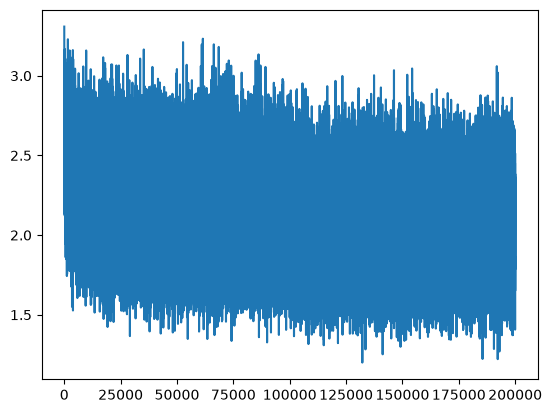

In [ ]:
plt.plot(stepi,lossi)

In [ ]:
@torch.no_grad()
def split_loss(split):
    x,y={
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte)
    }[split]
    emb=C[x]
    hpreact=emb.view(-1,inp_dimension)@W1+b1
    hpreact=bngain*(hpreact-bnmean_running)/bnstd_running+bnbias
    h=torch.tanh(hpreact)
    logits=h@W2+b2
    loss=F.cross_entropy(logits,y)
    print(split,loss.item())
split_loss('train')
split_loss('val')

train 2.1963648796081543
val 2.2085530757904053


In [ ]:
emb=C[Xtr]
h=torch.tanh(emb.view(-1,inp_dimension)@W1+b1)
logits=(h@W2+b2)
loss=F.cross_entropy(logits,Ytr)
loss

tensor(2.0370, grad_fn=<NllLossBackward0>)

In [ ]:
emb=C[Xdev]
h=torch.tanh(emb.view(-1,inp_dimension)@W1+b1)
logits=(h@W2+b2)
loss=F.cross_entropy(logits,Ydev)
loss

tensor(2.1032, grad_fn=<NllLossBackward0>)

In [ ]:
h[:32].mean(0,keepdim=True).shape

torch.Size([1, 200])

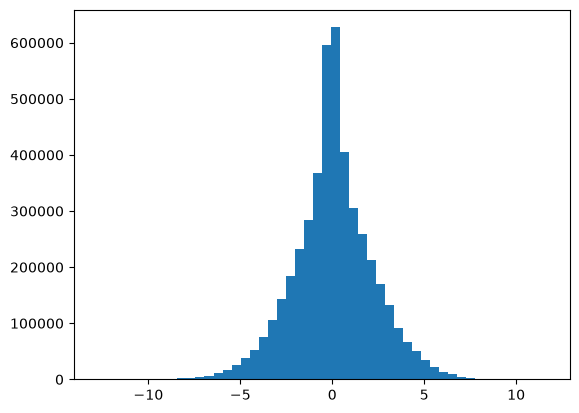

In [ ]:
hpreact=emb.view(-1,inp_dimension)@(W1)
plt.hist(hpreact.view(-1).tolist(),50);

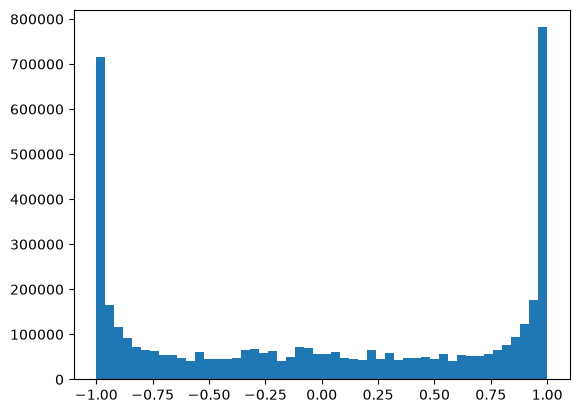

In [ ]:
h=torch.tanh(hpreact)
plt.hist(h.view(-1).tolist(),50);

In [ ]:
h.abs().shape

torch.Size([22799, 200])

In [ ]:
sample=torch.tensor([[2,3],[4,5]])
sample.shape

torch.Size([2, 2])

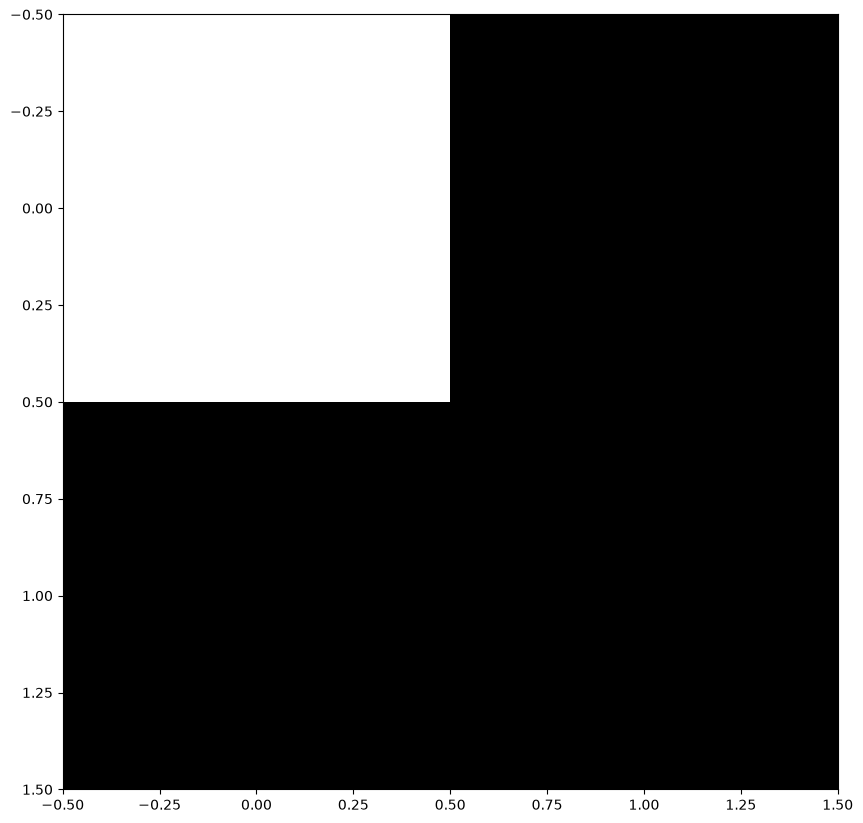

In [ ]:
plt.figure(figsize=(10,20))
plt.imshow(sample<=2,cmap='gray',interpolation='nearest')

In [183]:
class Linear:
    def __init__(self,fanin,fanout,bias=True):
        self.weight=torch.randn((fanin,fanout),generator=g)/(fanin**0.5)
        self.bias=torch.zeros(fanout) if bias else None
    def __call__(self,x):   
        self.out=x@self.weight
        if self.bias is not None:
            self.out+=self.bias
        return self.out
    def parameters(self):
        return [self.weight]+([] if self.bias is None else [self.bias])

class BatchNorm1D:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps=eps
        self.momentum=momentum
        self.training=True
        # parameters
        self.gamma=torch.ones(dim)
        self.beta=torch.zeros(dim)
        # buffers
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)
    def __call__(self,x):
        # calculate the forward pass
        if self.training:
            xmean=x.mean(0,keepdim=True)
            xvar=x.var(0,keepdim=True)
        else:
            xmean=self.running_mean
            xvar=self.running_var
        xhat=(x-xmean)/torch.sqrt(xvar+self.eps)
        self.out=self.gamma*xhat+self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean
                self.running_var=(1-self.momentum)*self.running_var+self.momentum*xvar
        return self.out
    def parameters(self):
        return [self.gamma,self.beta]

class Tanh:
    def __call__(self,x):
        self.out=torch.tanh(x)
        return self.out
    def parameters(self):
        return []

vocab_size=27
n_embd=10 # dimensionality of character embedding vectors
n_hidden=100 # the number of neurons in the hidden layer of MLP
block_size=3 # number of words passed to predict next word
g=torch.Generator().manual_seed(2147483647)

C=torch.randn((vocab_size,n_embd),generator=g)
layers=[
    Linear((block_size*n_embd),n_hidden), Tanh(),
    Linear(         n_hidden,n_hidden), BatchNorm1D(n_hidden), Tanh(),
    Linear(         n_hidden,n_hidden), BatchNorm1D(n_hidden), Tanh(),
    Linear(         n_hidden,n_hidden), BatchNorm1D(n_hidden), Tanh(),
    Linear(         n_hidden,n_hidden), BatchNorm1D(n_hidden), Tanh(),
    Linear(         n_hidden,vocab_size), BatchNorm1D(vocab_size),    
]

with torch.no_grad():
    layers[-1].gamma*=0.1
    # layers[-1].weight*=0.1
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight*=1

parameters=[C]+[p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

47351


In [190]:
max_steps=200000
batch_size=32
lossi=[]
ud=[]

for i in range(max_steps):

    # mini-batch construct
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]

    # forward pass
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad=None
    loss.backward()

    # update
    lr=0.1 if i<100000 else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    # track stats
    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
        
    if i>=1000:
        break

      0/ 200000: 3.2669


layer 1 (      Tanh): mean -0.03, std 0.62, saturated: 4.00%
layer 4 (      Tanh): mean -0.00, std 0.64, saturated: 3.03%
layer 7 (      Tanh): mean +0.00, std 0.65, saturated: 2.75%
layer 10 (      Tanh): mean -0.00, std 0.66, saturated: 1.81%
layer 13 (      Tanh): mean -0.00, std 0.66, saturated: 1.50%


Text(0.5, 1.0, 'activation distribution')

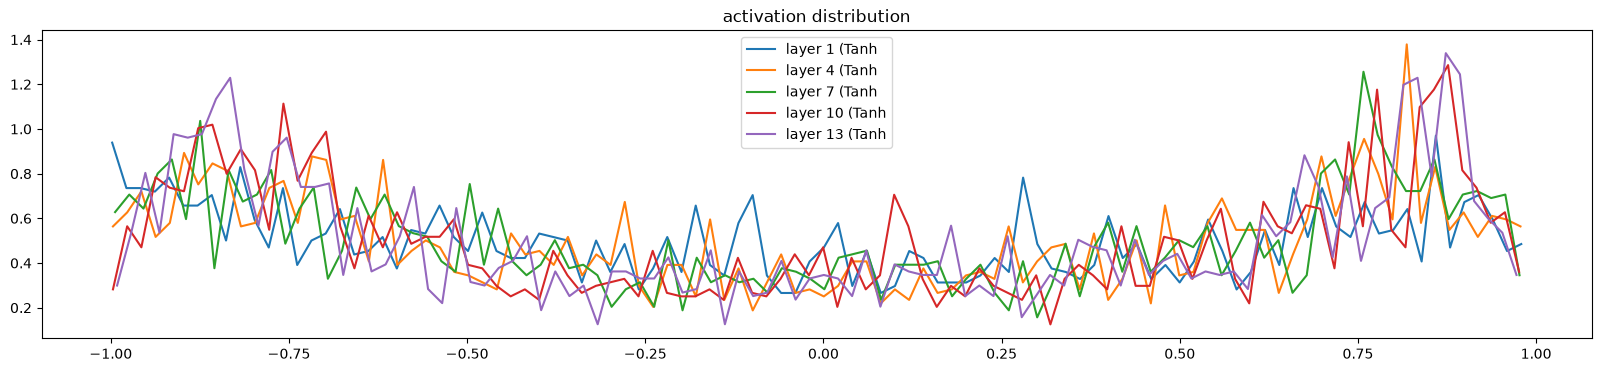

In [191]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 1 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 4 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 7 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 10 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 13 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

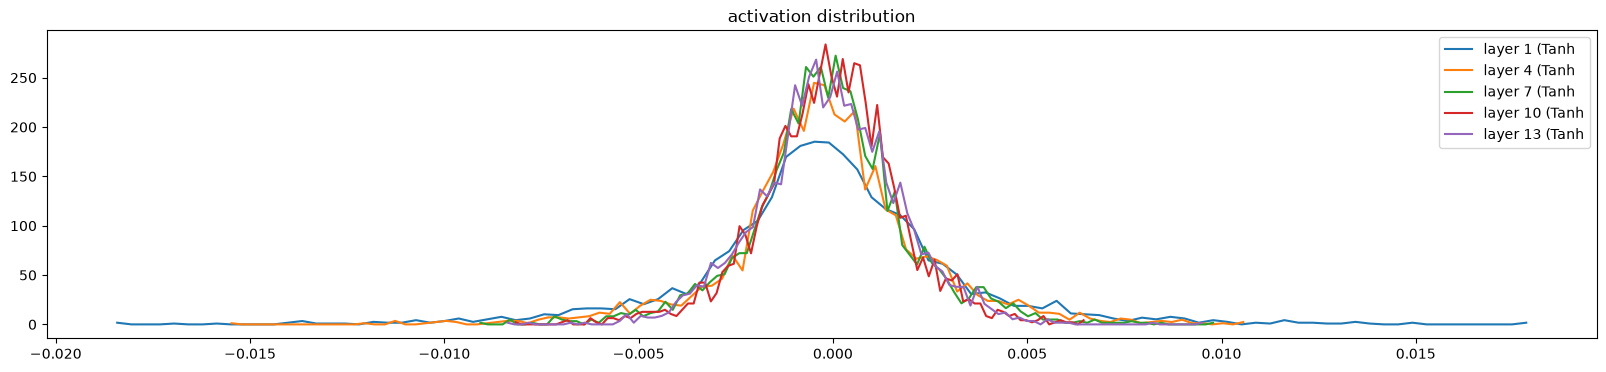

In [192]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

weight   (27, 10) | mean +0.000399 | std 1.174704e-02 | grad:data ratio 1.171765e-02
weight  (30, 100) | mean -0.000102 | std 1.020079e-02 | grad:data ratio 5.365843e-02
weight (100, 100) | mean -0.000177 | std 8.077972e-03 | grad:data ratio 7.873103e-02
weight (100, 100) | mean +0.000029 | std 6.424359e-03 | grad:data ratio 6.253496e-02
weight (100, 100) | mean +0.000057 | std 5.552335e-03 | grad:data ratio 5.448478e-02
weight (100, 100) | mean -0.000050 | std 4.788349e-03 | grad:data ratio 4.706166e-02
weight  (100, 27) | mean -0.000017 | std 1.023206e-02 | grad:data ratio 9.835548e-02


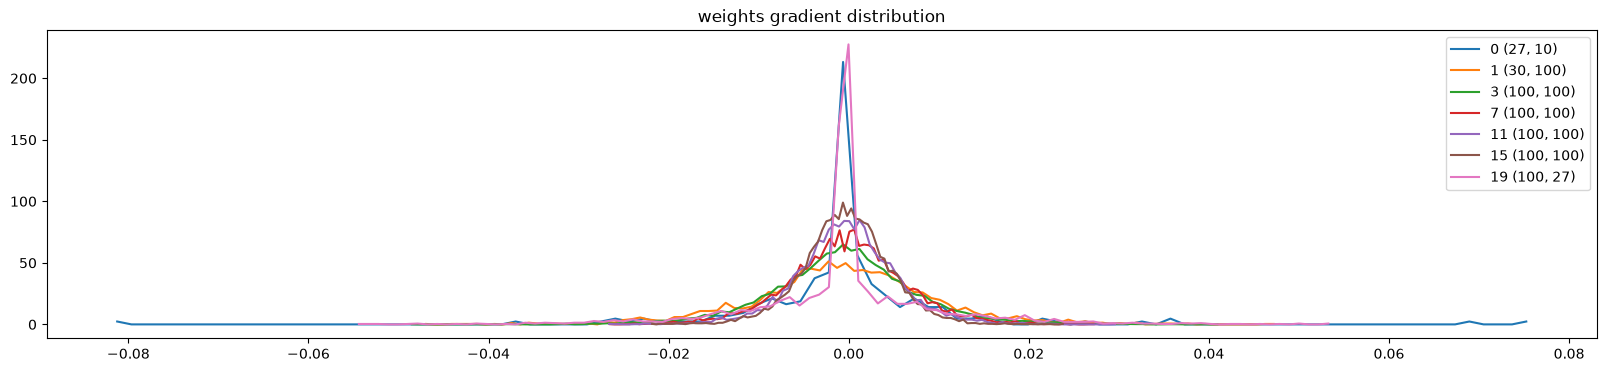

In [193]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

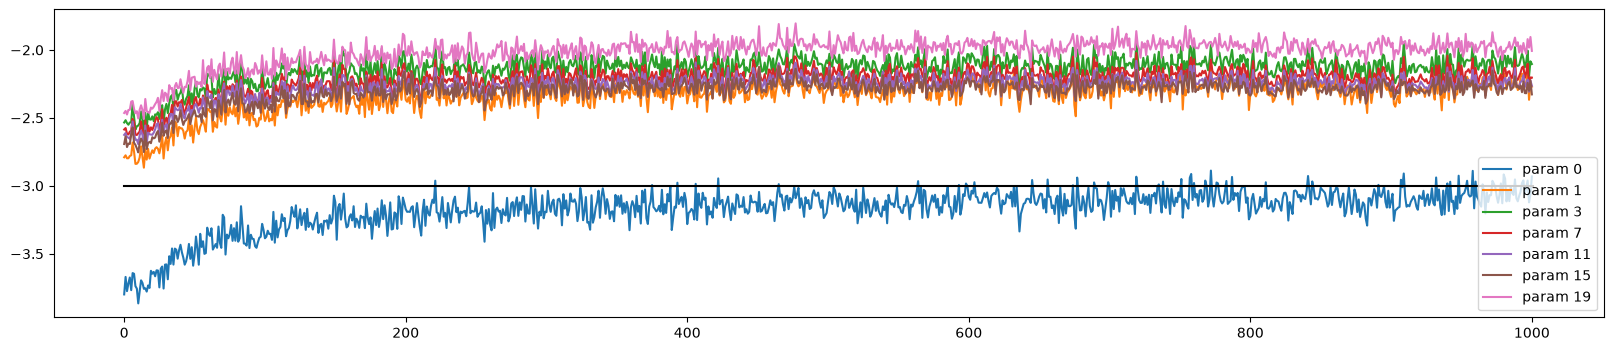

In [194]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);